/home/3afd6e9b-bb85-42fd-a9a7-a2d134b8b474


In [10]:
df = pd.read_csv('u.data', 
                 sep='\t', 
                 names=['user_id', 'movie_id', 'rating', 'timestamp'])

print("Veri yüklendi!")
print("Satır sayısı:", len(df))
print(df.head())

Veri yüklendi!
Satır sayısı: 100000
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596


Kaç kullanıcı var: 943
Kaç film var: 1682
Puan dağılımı:
1     6110
2    11370
3    27145
4    34174
5    21201
Name: rating, dtype: int64


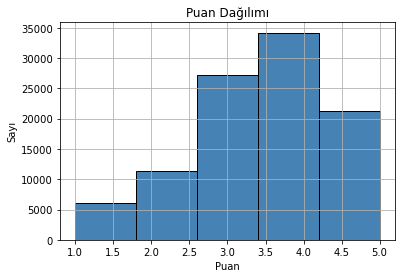

In [11]:
print("Kaç kullanıcı var:", df['user_id'].nunique())
print("Kaç film var:", df['movie_id'].nunique())
print("Puan dağılımı:")
print(df['rating'].value_counts().sort_index())

# Görselleştir
df['rating'].hist(bins=5, color='steelblue', edgecolor='black')
plt.xlabel('Puan')
plt.ylabel('Sayı')
plt.title('Puan Dağılımı')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

# Girdi ve çıktı
X = df[['user_id', 'movie_id']].values
y = df['rating'].values

# %80 eğitim, %20 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Eğitim seti:", len(X_train), "puan")
print("Test seti:", len(X_test), "puan")
print("İlk 3 girdi:", X_train[:3])
print("İlk 3 gerçek puan:", y_train[:3])

Eğitim seti: 80000 puan
Test seti: 20000 puan
İlk 3 girdi: [[ 807 1411]
 [ 474  659]
 [ 463  268]]
İlk 3 gerçek puan: [1 5 4]


In [13]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=20,
    verbose=True,
    random_state=42
)

print("Eğitim başlıyor...")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nOrtalama hata: {mae:.3f} puan")

Eğitim başlıyor...
Iteration 1, loss = 32.26071708
Iteration 2, loss = 1.42442804
Iteration 3, loss = 1.07627116
Iteration 4, loss = 0.72719370
Iteration 5, loss = 0.67793228
Iteration 6, loss = 0.66650631
Iteration 7, loss = 0.67904872
Iteration 8, loss = 0.67560040
Iteration 9, loss = 0.68101186
Iteration 10, loss = 0.71317685
Iteration 11, loss = 0.70160852
Iteration 12, loss = 0.75119335
Iteration 13, loss = 0.79236727
Iteration 14, loss = 0.81053134
Iteration 15, loss = 0.75660181
Iteration 16, loss = 0.70133015
Iteration 17, loss = 0.78656691
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

Ortalama hata: 1.075 puan


In [14]:
model2 = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    learning_rate_init=0.0001,  # 10 kat küçülttük
    max_iter=50,                 # daha fazla epoch
    verbose=True,
    random_state=42
)

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
mae2 = mean_absolute_error(y_test, y_pred2)
print(f"\nYeni ortalama hata: {mae2:.3f} puan")

Iteration 1, loss = 188.82002971
Iteration 2, loss = 3.09027785
Iteration 3, loss = 1.79223247
Iteration 4, loss = 1.64881250
Iteration 5, loss = 1.57679046
Iteration 6, loss = 1.52221397
Iteration 7, loss = 1.47974286
Iteration 8, loss = 1.44111476
Iteration 9, loss = 1.40200800
Iteration 10, loss = 1.35811608
Iteration 11, loss = 1.31058578
Iteration 12, loss = 1.25914222
Iteration 13, loss = 1.21035852
Iteration 14, loss = 1.15462587
Iteration 15, loss = 1.09522023
Iteration 16, loss = 1.03624317
Iteration 17, loss = 0.97326601
Iteration 18, loss = 0.90133910
Iteration 19, loss = 0.84811124
Iteration 20, loss = 0.79052113
Iteration 21, loss = 0.75189012
Iteration 22, loss = 0.71616629
Iteration 23, loss = 0.68349196
Iteration 24, loss = 0.67179572
Iteration 25, loss = 0.65354635
Iteration 26, loss = 0.65380074
Iteration 27, loss = 0.64725803
Iteration 28, loss = 0.63942177
Iteration 29, loss = 0.63843264
Iteration 30, loss = 0.63843279
Iteration 31, loss = 0.63866937
Iteration 32, l

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


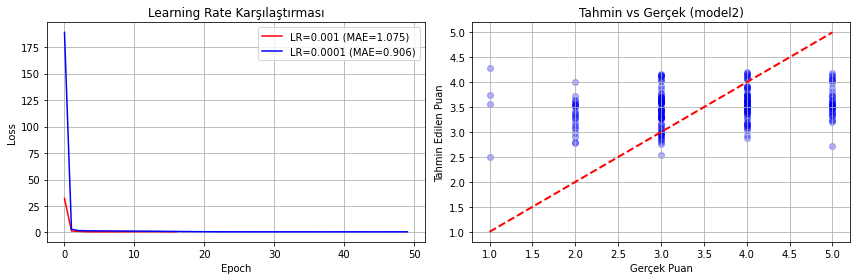

Model 1 (LR=0.001): MAE = 1.075
Model 2 (LR=0.0001): MAE = 0.906
İyileşme: 15.7%


In [15]:
# İki modeli karşılaştır
plt.figure(figsize=(12, 4))

# Sol: loss grafikleri
plt.subplot(1, 2, 1)
plt.plot(model.loss_curve_, 'r-', label=f'LR=0.001 (MAE={mae:.3f})')
plt.plot(model2.loss_curve_, 'b-', label=f'LR=0.0001 (MAE={mae2:.3f})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Rate Karşılaştırması')
plt.legend()
plt.grid(True)

# Sağ: tahmin vs gerçek
plt.subplot(1, 2, 2)
plt.scatter(y_test[:200], y_pred2[:200], alpha=0.3, color='blue')
plt.plot([1, 5], [1, 5], 'r--', linewidth=2)  # mükemmel tahmin çizgisi
plt.xlabel('Gerçek Puan')
plt.ylabel('Tahmin Edilen Puan')
plt.title('Tahmin vs Gerçek (model2)')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Model 1 (LR=0.001): MAE = {mae:.3f}")
print(f"Model 2 (LR=0.0001): MAE = {mae2:.3f}")
print(f"İyileşme: {((mae-mae2)/mae*100):.1f}%")

In [16]:
for yapi in [(8,), (32,), (64, 32), (128, 64, 32)]:
    m = MLPRegressor(hidden_layer_sizes=yapi, 
                     activation='relu',
                     learning_rate_init=0.0001,
                     max_iter=30,
                     random_state=42)
    m.fit(X_train, y_train)
    mae_m = mean_absolute_error(y_test, m.predict(X_test))
    print(f"{str(yapi):20} → MAE: {mae_m:.3f}")

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


(8,)                 → MAE: 1.560


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


(32,)                → MAE: 0.928


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


(64, 32)             → MAE: 0.905
(128, 64, 32)        → MAE: 0.921


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [17]:
# Kullanıcı 196 hangi filmleri beğenir?
kullanici = 196
filmler = [1, 50, 100, 200, 300]

for film in filmler:
    tahmin = model2.predict([[kullanici, film]])[0]
    print(f"Kullanıcı {kullanici}, Film {film} → Tahmini puan: {tahmin:.1f}")

Kullanıcı 196, Film 1 → Tahmini puan: 3.9
Kullanıcı 196, Film 50 → Tahmini puan: 3.7
Kullanıcı 196, Film 100 → Tahmini puan: 3.6
Kullanıcı 196, Film 200 → Tahmini puan: 3.7
Kullanıcı 196, Film 300 → Tahmini puan: 3.5


In [18]:
# Kullanıcı 196 hangi filmleri beğenir?
kullanici = 196
filmler = [1, 50, 100, 200, 300, 500]

print(f"Kullanıcı {kullanici} için tahminler:")
print("-" * 35)
for film in filmler:
    tahmin = model2.predict([[kullanici, film]])[0]
    tahmin = max(1, min(5, tahmin))  # 1-5 arasında tut
    yildiz = "⭐" * round(tahmin)
    print(f"Film {film:4d} → {tahmin:.1f} puan  {yildiz}")

# Gerçek puanlarla karşılaştır
print("\nGerçek puanlar (eğer izlediyse):")
gercek = df[(df['user_id'] == kullanici) & (df['movie_id'].isin(filmler))]
print(gercek[['movie_id', 'rating']])

Kullanıcı 196 için tahminler:
-----------------------------------
Film    1 → 3.9 puan  ⭐⭐⭐⭐
Film   50 → 3.7 puan  ⭐⭐⭐⭐
Film  100 → 3.6 puan  ⭐⭐⭐⭐
Film  200 → 3.7 puan  ⭐⭐⭐⭐
Film  300 → 3.5 puan  ⭐⭐⭐
Film  500 → 3.5 puan  ⭐⭐⭐⭐

Gerçek puanlar (eğer izlediyse):
Empty DataFrame
Columns: [movie_id, rating]
Index: []


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi yükle
df = pd.read_csv('u.data', sep='\t', 
                 names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Kullanıcı-film matrisi oluştur
# Satır = kullanıcı, Sütun = film
n_users = df['user_id'].max()
n_movies = df['movie_id'].max()

R = np.zeros((n_users, n_movies))
for _, row in df.iterrows():
    R[int(row['user_id'])-1, int(row['movie_id'])-1] = row['rating']

# Normalize et — her kullanıcının ortalamasını çıkar
R_mean = R.mean(axis=1, keepdims=True)
R_norm = R - R_mean

print("Kullanıcı-film matrisi boyutu:", R.shape)
print("Örnek kullanıcı vektörü (ilk 10 film):", R[0, :10])

Kullanıcı-film matrisi boyutu: (943, 1682)
Örnek kullanıcı vektörü (ilk 10 film): [5. 3. 4. 3. 3. 5. 4. 1. 5. 3.]


In [20]:
# HEBBIAN KURALI
# W matrisi: filmler arası ilişkiyi öğrenecek
# Boyut küçültelim — ilk 50 filmi kullanalım
n_features = 50
X = R_norm[:, :n_features]  # 943 kullanıcı, 50 film

# Ağırlık matrisini başlat
np.random.seed(42)
W_hebb = np.random.randn(n_features, n_features) * 0.01

# Öğrenme oranı
eta = 0.0001

# Hebbian öğrenmesi
losses = []
for epoch in range(100):
    total = 0
    for i in range(len(X)):
        x = X[i]              # 1 kullanıcı vektörü (50 film)
        y = W_hebb @ x        # çıktı
        
        # Hebbian kuralı: ΔW = η * y * xᵀ
        dW = eta * np.outer(y, x)
        W_hebb += dW
        
        total += np.sum(np.abs(dW))
    losses.append(total)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: W değişimi = {total:.4f}, W max = {np.max(np.abs(W_hebb)):.4f}")

print("\nHebbian bitti!")
print("W matrisi max değeri:", np.max(np.abs(W_hebb)))

Epoch 0: W değişimi = 65.4086, W max = 0.2902
Epoch 10: W değişimi = 756404717584651.5000, W max = 3491612272656.2729
Epoch 20: W değişimi = 9105880951396448522653925376.0000, W max = 42033325472557368969527296.0000
Epoch 30: W değişimi = 109619977207138988027537459127009840988160.0000, W max = 506012785016189866339965094242321170432.0000
Epoch 40: W değişimi = 1319646003174556795316532408237234414002007386127073280.0000, W max = 6091569860847895674280289536529707085215117602717696.0000
Epoch 50: W değişimi = 15886388759266876179123015625360214201484665081171524161028529061888.0000, W max = 73332580654861120507450906197499304210018706512820665976906317824.0000
Epoch 60: W değişimi = 191246248769320700552393776941699341938313201237812415148816855300458956151848960.0000, W max = 882804844784814589631121400824116577981389551369996935001594258551833576341504.0000
Epoch 70: W değişimi = 2302293379733758191362855732475093137665652109915430947422361394878920165213076598158111277056.0000, W ma

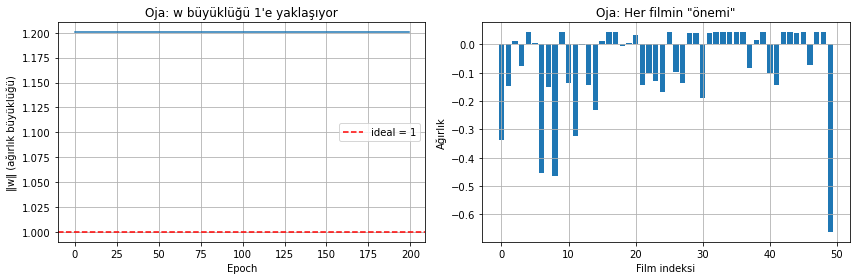

w büyüklüğü: 1.2004156787268783
En önemli 5 film (indeks): [49  8  6  0 11]
Bu filmlerin ağırlıkları: [-0.66133918 -0.46536076 -0.45495498 -0.33652931 -0.32458775]


In [21]:
# OJA KURALI
# Hebbian + normalleştirme = patlamaz + PCA öğrenir

# Tek bir nöron — verinin en önemli yönünü bul
np.random.seed(42)
w_oja = np.random.randn(n_features) * 0.01
w_oja = w_oja / np.linalg.norm(w_oja)  # başlangıçta normalize et

eta = 0.01
w_norms = []

for epoch in range(200):
    for i in range(len(X)):
        x = X[i]
        y = w_oja @ x          # skaler çıktı
        
        # Oja kuralı: ΔW = η * (y*x - y²*w)
        # İkinci terim frenleme yapıyor
        dw = eta * (y * x - y**2 * w_oja)
        w_oja += dw
    
    w_norms.append(np.linalg.norm(w_oja))

# Görselleştir
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w_norms)
plt.xlabel('Epoch')
plt.ylabel('‖w‖ (ağırlık büyüklüğü)')
plt.title('Oja: w büyüklüğü 1\'e yaklaşıyor')
plt.axhline(y=1, color='r', linestyle='--', label='ideal = 1')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(range(n_features), w_oja)
plt.xlabel('Film indeksi')
plt.ylabel('Ağırlık')
plt.title('Oja: Her filmin "önemi"')
plt.grid(True)

plt.tight_layout()
plt.show()

print("w büyüklüğü:", np.linalg.norm(w_oja))
print("En önemli 5 film (indeks):", np.argsort(np.abs(w_oja))[-5:][::-1])
print("Bu filmlerin ağırlıkları:", w_oja[np.argsort(np.abs(w_oja))[-5:][::-1]])

Epoch 0 tamamlandı
Epoch 10 tamamlandı
Epoch 20 tamamlandı
Epoch 30 tamamlandı
Epoch 40 tamamlandı

Anti-Hebbian bitti!


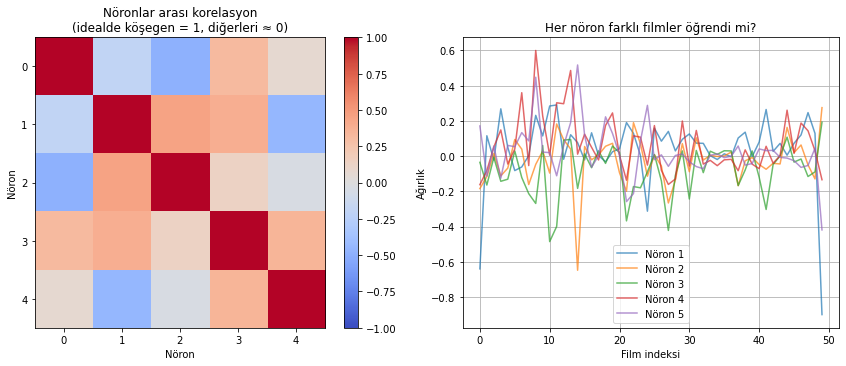

In [22]:
# ANTI-HEBBIAN + OJA = Foldiak'ın kuralı
# W: girdi→çıktı bağlantıları (Oja ile güncellenir)
# B: çıktılar arası bağlantılar (Anti-Hebbian ile güncellenir)

np.random.seed(42)
n_out = 5        # 5 nöron — 5 farklı yön bulsun
n_in = n_features  # 50 film

W_foldiak = np.random.randn(n_out, n_in) * 0.01
B_foldiak = np.zeros((n_out, n_out))  # başta bağlantı yok

eta_W = 0.001   # W için öğrenme oranı
eta_B = 0.001   # B için öğrenme oranı

I = np.eye(n_out)  # birim matris

for epoch in range(50):
    for i in range(len(X)):
        x = X[i]
        
        # Forward: y = (I-B)⁻¹ W x
        # Nöronlar birbirini baskıladıktan sonraki çıktı
        T = np.linalg.inv(I - B_foldiak) @ W_foldiak
        y = T @ x
        
        # W güncelle — Oja kuralı
        for k in range(n_out):
            dW = eta_W * (y[k] * x - y[k]**2 * W_foldiak[k])
            W_foldiak[k] += dW
        
        # B güncelle — Anti-Hebbian kuralı
        dB = np.outer(y, y)
        for k in range(n_out):
            dB[k, k] = y[k]**2 - 1  # köşegen farklı
        B_foldiak = (1 - eta_B) * B_foldiak - eta_B * dB
        np.fill_diagonal(B_foldiak, 0)  # öz-bağlantı yok
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} tamamlandı")

print("\nAnti-Hebbian bitti!")

# Sonuçları görselleştir
T_final = np.linalg.inv(I - B_foldiak) @ W_foldiak

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.corrcoef(T_final), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Nöronlar arası korelasyon\n(idealde köşegen = 1, diğerleri ≈ 0)')
plt.xlabel('Nöron')
plt.ylabel('Nöron')

plt.subplot(1, 2, 2)
for k in range(n_out):
    plt.plot(T_final[k], label=f'Nöron {k+1}', alpha=0.7)
plt.xlabel('Film indeksi')
plt.ylabel('Ağırlık')
plt.title('Her nöron farklı filmler öğrendi mi?')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


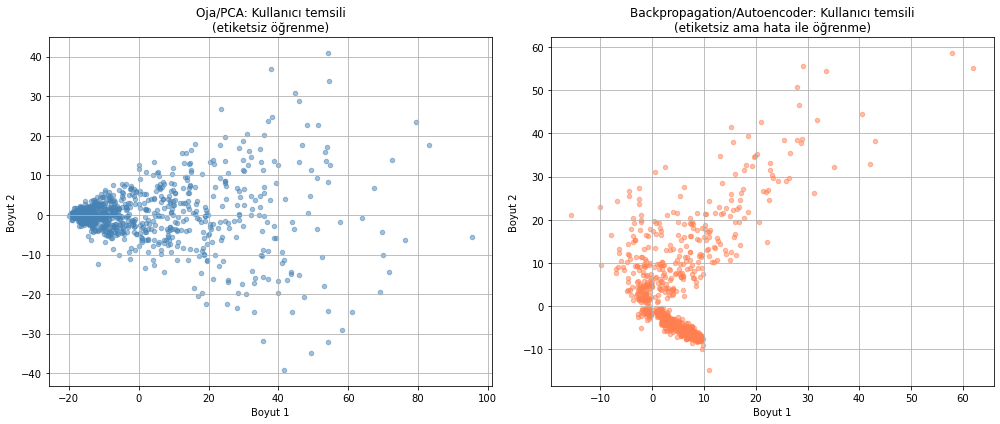

PCA açıklanan varyans: 0.27151017355202567


In [23]:
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Veriyi hazırla
scaler = StandardScaler()
X_scaled = scaler.fit_transform(R_norm)

# --- YÖNTEM 1: Oja (PCA ile yaklaşık) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- YÖNTEM 2: Backpropagation (Autoencoder) ---
# Girdi → 2 boyut → tekrar girdi
# "Encoder" kısmı bizim 2 boyutlu temsilimiz
from sklearn.neural_network import MLPRegressor

autoencoder = MLPRegressor(
    hidden_layer_sizes=(32, 2, 32),  # darboğaz = 2 nöron
    activation='relu',
    max_iter=50,
    random_state=42,
    verbose=False
)
autoencoder.fit(X_scaled, X_scaled)

# 2 boyutlu temsili çıkar
# İlk 2 katmana kadar çalıştır
import warnings
warnings.filterwarnings('ignore')

# Manuel forward pass — 2 boyutlu katmana kadar
W1 = autoencoder.coefs_[0]  # girdi → 32
b1 = autoencoder.intercepts_[0]
W2 = autoencoder.coefs_[1]  # 32 → 2
b2 = autoencoder.intercepts_[1]

h1 = np.maximum(0, X_scaled @ W1 + b1)  # ReLU
X_ae = h1 @ W2 + b2  # 2 boyutlu temsil

# --- GÖRSELLEŞTİR ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=20, c='steelblue')
plt.xlabel('Boyut 1')
plt.ylabel('Boyut 2')
plt.title('Oja/PCA: Kullanıcı temsili\n(etiketsiz öğrenme)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_ae[:, 0], X_ae[:, 1], alpha=0.5, s=20, c='coral')
plt.xlabel('Boyut 1')
plt.ylabel('Boyut 2')
plt.title('Backpropagation/Autoencoder: Kullanıcı temsili\n(etiketsiz ama hata ile öğrenme)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("PCA açıklanan varyans:", pca.explained_variance_ratio_.sum())